# Traffic Sign Recognition

Цель работы: разработка модели распознавания дорожных знаков с использованием современных архитектур глубокого обучения

In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os
import time
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
import torchvision
from torchvision import datasets, transforms, models
from torchvision.transforms.functional import to_pil_image

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

#проверяем GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"используемое устройство: {device}")

#создаем папки для проекта на диске
PROJECT_DIR = "/content/drive/MyDrive/traffic_sign_project"
for folder in ["data", "models", "results", "plots"]:
    os.makedirs(os.path.join(PROJECT_DIR, folder), exist_ok=True)
print("структура папок готова")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
используемое устройство: cuda
структура папок готова


In [ ]:
!pip install ultralytics gradio

## Подготовка набора данных

In [2]:
zip_path = "/content/drive/MyDrive/traffic_sign_project/traffic-signs-classification.zip"
extract_path = "/content/traffic_dataset"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("датасет успешно распакован")
else:
    print(f"архив не найден по пути: {zip_path}")

датасет успешно распакован


In [ ]:
#задаем фиксированный seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

#трансформации для обучения с аугментацией
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#трансформации для валидации и теста. без аугментации, только ресайз и нормализация
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#загружаем базовый датасет
full_dataset = datasets.ImageFolder(root="/content/traffic_dataset/myData")
dataset_size = len(full_dataset)
num_classes = len(full_dataset.classes)

#честное разбиение индексов
train_size = int(0.7 * dataset_size)
val_size = int(0.15 * dataset_size)
test_size = dataset_size - train_size - val_size

train_idx, val_idx, test_idx = random_split(range(dataset_size), [train_size, val_size, test_size])

#создаем подвыборки с правильными трансформациями
train_dataset = torch.utils.data.Subset(datasets.ImageFolder(root="/content/traffic_dataset/myData", transform=train_transform), train_idx)
val_dataset = torch.utils.data.Subset(datasets.ImageFolder(root="/content/traffic_dataset/myData", transform=val_test_transform), val_idx)
test_dataset = torch.utils.data.Subset(datasets.ImageFolder(root="/content/traffic_dataset/myData", transform=val_test_transform), test_idx)

#даталоадеры
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Всего картинок: {dataset_size} | Классов: {num_classes}")
print(f"Обучение: {len(train_dataset)} | Валидация: {len(val_dataset)} | Тест: {len(test_dataset)}")

Всего картинок: 73139 | Классов: 43
Обучение: 51197 | Валидация: 10970 | Тест: 10972


# Обучение всех моделей, выбор лучшей

In [ ]:
import gc
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import time
import pandas as pd

def get_model_architecture(name, num_classes):
    if name == "ResNet50":
        model = models.resnet50(weights="IMAGENET1K_V2")
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "DenseNet121":
        model = models.densenet121(weights="IMAGENET1K_V1")
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif name == "MobileNetV3-Small":
        model = models.mobilenet_v3_small(weights="IMAGENET1K_V1")
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
    elif name == "EfficientNet-B0":
        model = models.efficientnet_b0(weights="IMAGENET1K_V1")
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    elif name == "ViT-B16":
        model = models.vit_b_16(weights="IMAGENET1K_V1")
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    return model

model_names = ["ResNet50", "DenseNet121", "MobileNetV3-Small", "EfficientNet-B0", "ViT-B16"]
comparison_rows = []
best_acc = 0.0
best_model_name = ""
epochs_count = 2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))

for name in model_names:
    print(f"\n>>> СТАРТ: {name} <<<")
    try:
        model = get_model_architecture(name, num_classes).to(device)
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
        optimizer = optim.AdamW(model.parameters(), lr=3e-4)

        for epoch in range(epochs_count):
            model.train()
            running_loss = 0.0
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                running_loss += loss.item()
            print(f"Эпоха {epoch+1}/{epochs_count} завершена для {name}")

        model.eval()
        test_correct, test_total = 0, 0
        start_time = time.time()
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                preds = torch.argmax(outputs, dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)

        fps = test_total / (time.time() - start_time)
        final_test_acc = (test_correct / test_total) * 100
        model_size_mb = sum(p.nelement() * p.element_size() for p in model.parameters()) / (1024**2)

        if final_test_acc > best_acc:
            best_acc = final_test_acc
            best_model_name = name
            torch.save(model.state_dict(), "/content/drive/MyDrive/traffic_sign_project/models/best_model.pth")

        comparison_rows.append({"Модель": name, "Accuracy %": round(final_test_acc, 2), "FPS": round(fps, 1), "Size MB": round(model_size_mb, 1)})
        print(f"Завершено: {name} | Acc: {final_test_acc:.2f}%")

        del model, optimizer
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    except Exception as e:
        print(f"Ошибка при обучении {name}: {e}")

df_comparison = pd.DataFrame(comparison_rows)
display(df_comparison)


>>> СТАРТ: ResNet50 <<<


/tmp/ipykernel_3591/3297302815.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == 'cuda'))


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 170MB/s]
/tmp/ipykernel_3591/3297302815.py:49: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == 'cuda')):


Эпоха 1/2 завершена для ResNet50
Эпоха 2/2 завершена для ResNet50
Завершено: ResNet50 | Acc: 97.93%

>>> СТАРТ: DenseNet121 <<<
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


...

100%|██████████| 20.5M/20.5M [00:00<00:00, 118MB/s] 


Эпоха 1/2 завершена для EfficientNet-B0
Эпоха 2/2 завершена для EfficientNet-B0
Завершено: EfficientNet-B0 | Acc: 99.36%

>>> СТАРТ: ViT-B16 <<<
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 83.3MB/s]


Эпоха 1/2 завершена для ViT-B16
Эпоха 2/2 завершена для ViT-B16
Завершено: ViT-B16 | Acc: 96.04%


,Модель,Accuracy %,FPS,Size MB
0,ResNet50,97.93,270.2,90.0
1,DenseNet121,99.66,273.4,26.7
2,MobileNetV3-Small,99.74,520.2,6.0
3,EfficientNet-B0,99.36,440.3,15.5
4,ViT-B16,96.04,73.8,327.4


Веса для MobileNetV3-Small успешно загружены.

--- МЕТРИКИ ДЛЯ МОДЕЛИ (MobileNetV3-Small) ---
Accuracy : 0.9974
Precision: 0.9975
Recall   : 0.9974
F1-score : 0.9975


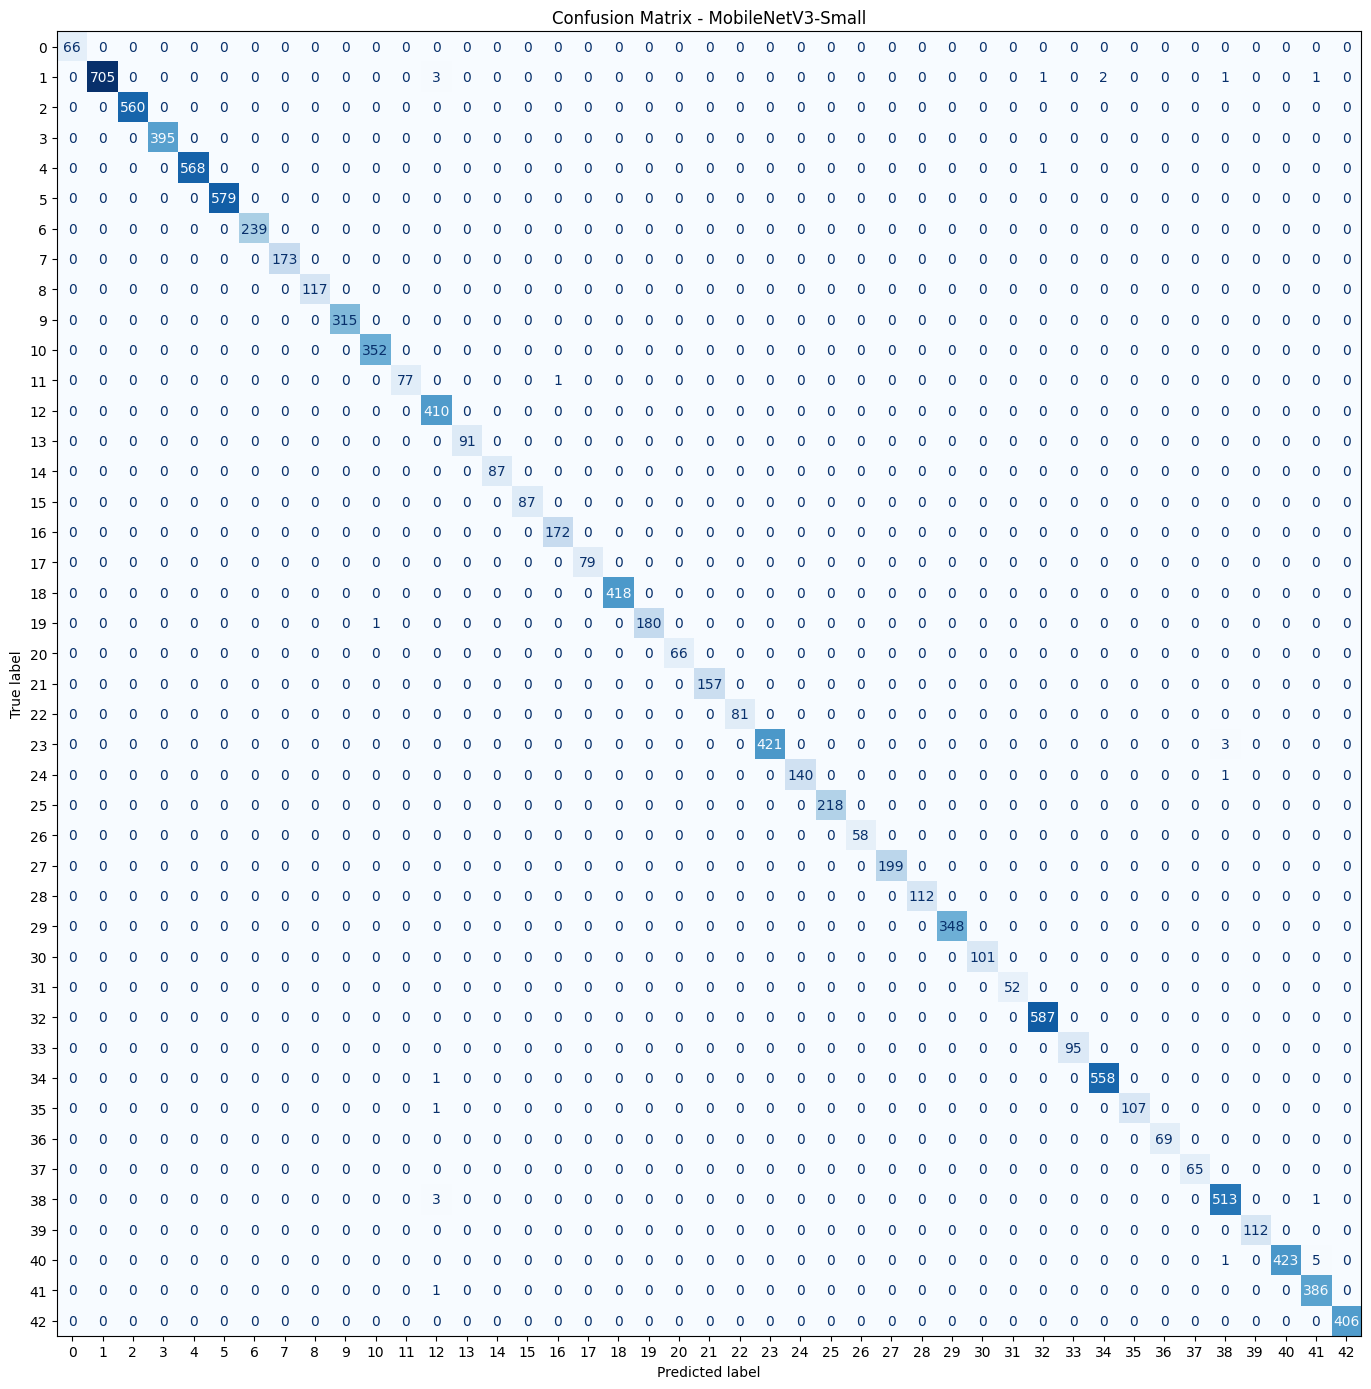

In [ ]:
#проверяем, определена ли лучшая модель
try:
    selected_model_name = best_model_name
except NameError:
    selected_model_name = "ResNet50"
    print(f"Внимание: обучение было прервано. Используем {selected_model_name} по умолчанию.")

#инициализируем архитектуру
best_model = get_model_architecture(selected_model_name, num_classes=num_classes).to(device)

#пытаемся загрузить веса, если они успели сохраниться
weights_path = "/content/drive/MyDrive/traffic_sign_project/models/best_model.pth"
if os.path.exists(weights_path):
    best_model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"Веса для {selected_model_name} успешно загружены.")
else:
    print("Веса не найдены. Модель будет использовать веса ImageNet.")

best_model.eval()

y_true, y_pred, y_conf = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = best_model(images)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_conf.extend(confidence.cpu().numpy())

#считаем и выводим метрики
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"\n--- МЕТРИКИ ДЛЯ МОДЕЛИ ({selected_model_name}) ---")
print(f"Accuracy : {acc:.4f}\nPrecision: {prec:.4f}\nRecall   : {rec:.4f}\nF1-score : {f1:.4f}")

#сохраняем отчет классификации в csv
report_df = pd.DataFrame(classification_report(y_true, y_pred, output_dict=True, zero_division=0)).transpose()
report_df.to_csv("/content/drive/MyDrive/traffic_sign_project/results/classification_report.csv")

#строим Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title(f"Confusion Matrix - {selected_model_name}")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/traffic_sign_project/plots/confusion_matrix.png")
plt.show()

Всего ошибок на тесте: 28


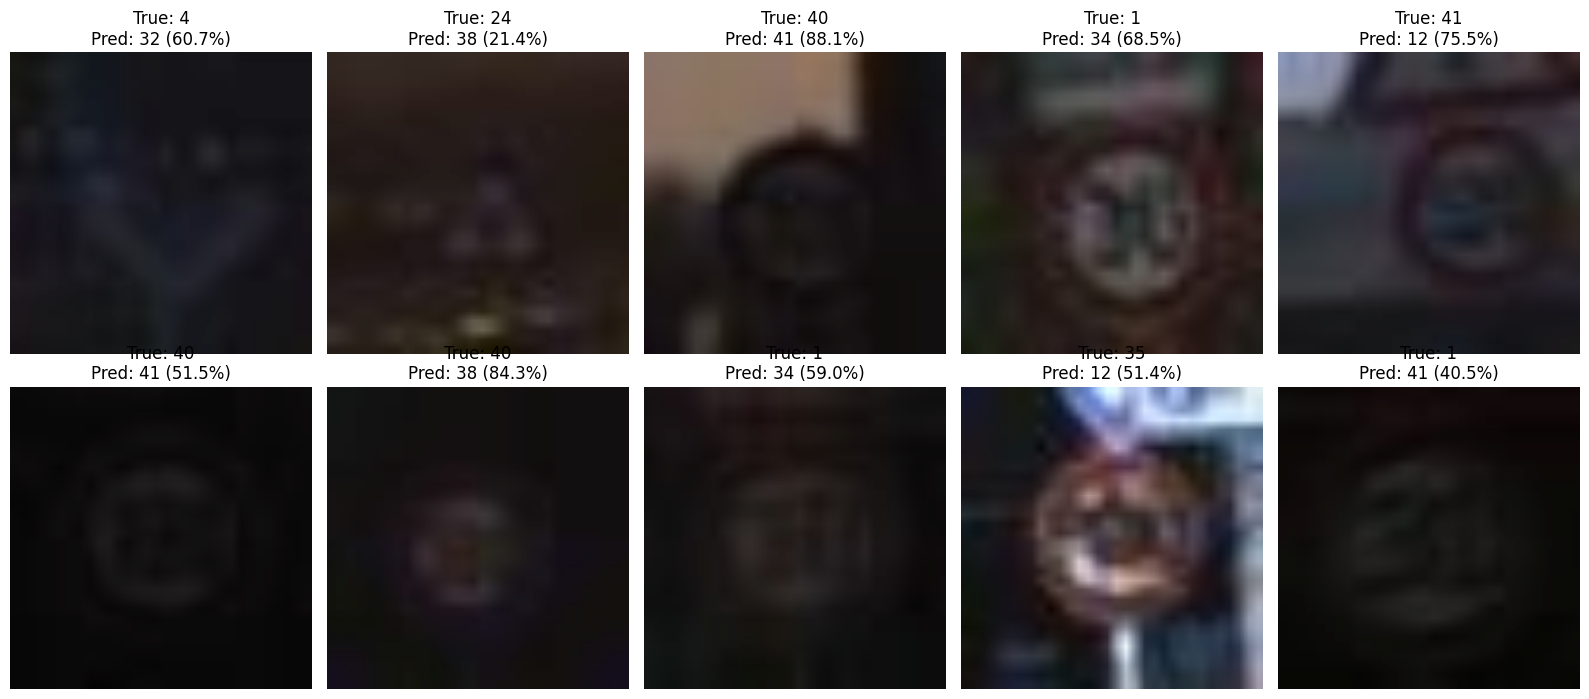

In [ ]:
wrong_images, wrong_true, wrong_pred, wrong_prob = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = best_model(images.to(device))
        probs = torch.softmax(outputs, dim=1)
        conf, preds = torch.max(probs, 1)

        for img, t, p, c in zip(images, labels, preds.cpu(), conf.cpu()):
            if t != p:
                wrong_images.append(img)
                wrong_true.append(t.item())
                wrong_pred.append(p.item())
                wrong_prob.append(c.item())

print(f"Всего ошибок на тесте: {len(wrong_images)}")

#рисуем первые 10 ошибок
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
count = min(10, len(wrong_images))

if count > 0:
    plt.figure(figsize=(16, 7))
    for i in range(count):
        plt.subplot(2, 5, i + 1)
        img = wrong_images[i].permute(1, 2, 0).numpy()
        img = std * img + mean  #денормализация для корректного отображения цветов
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"True: {wrong_true[i]}\nPred: {wrong_pred[i]} ({wrong_prob[i]*100:.1f}%)")
        plt.axis("off")
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/traffic_sign_project/plots/wrong_predictions.png")
    plt.show()

# Подготовка данных и обучение детектора YOLO

Для определения знака на фото

In [9]:
import os
import shutil
from ultralytics import YOLO
import torch

#подготавливаем правильную структуру для YOLO
YOLO_ROOT = "/content/yolo_data"
IMG_DIR = os.path.join(YOLO_ROOT, "images")
LBL_DIR = os.path.join(YOLO_ROOT, "labels")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(LBL_DIR, exist_ok=True)

print("Организую структуру данных для YOLO...")
base_ds = "/content/traffic_dataset/myData"

for class_id in range(43):
    class_path = os.path.join(base_ds, str(class_id))
    if not os.path.exists(class_path): continue

    for img_name in os.listdir(class_path):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            #путь к исходному фото
            src_img = os.path.join(class_path, img_name)
            #сздаем уникальное имя
            unique_name = f"{class_id}_{img_name}"
            dst_img = os.path.join(IMG_DIR, unique_name)

            #создаем симлинк
            if not os.path.exists(dst_img):
                os.symlink(src_img, dst_img)

            #создаем файл метки
            txt_name = os.path.splitext(unique_name)[0] + '.txt'
            with open(os.path.join(LBL_DIR, txt_name), 'w') as f:
                f.write(f"{class_id} 0.5 0.5 0.85 0.85\n")

#обновляем YAML на новую структуру
data_yaml = f"""
train: {IMG_DIR}
val: {IMG_DIR}
nc: 43
names: {[str(i) for i in range(43)]}
"""
with open('traffic_data.yaml', 'w') as f:
    f.write(data_yaml)

#запускаем обучение
print("Начинаю обучение детектора...")
detector = YOLO('yolov8n.pt')
detector.train(data='traffic_data.yaml', epochs=5, imgsz=224, batch=32, device=device)

#сохраняем
os.makedirs(os.path.join(PROJECT_DIR, "models"), exist_ok=True)
save_path = os.path.join(PROJECT_DIR, "models/yolo_traffic_fixed.pt")
torch.save(detector.model.state_dict(), save_path)
print(f"Модель сохранена: {save_path}")

Организую структуру данных для YOLO...
Начинаю обучение детектора...engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=traffic_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plo

Подгружаем свежеобученные веса детектора в Gradio

In [6]:
import os
from ultralytics import YOLO

#исправляем импорты и пути для Gradio
custom_yolo_path = os.path.join(PROJECT_DIR, "models/yolo_traffic_fixed.pt")

if os.path.exists(custom_yolo_path):
    yolo_model = YOLO(custom_yolo_path)
    print("интерфейс успешно переключен на обученную YOLO")
else:
    print("обученная модель еще не создана или не найдена")

интерфейс успешно переключен на обученную YOLO


# Создаем градио

In [ ]:
import gradio as gr
from ultralytics import YOLO
import numpy as np
import torch
from PIL import Image, ImageOps, ImageFilter
import os
import pandas as pd
from torchvision import transforms, datasets
import cv2

#пути проекта
PROJECT_DIR = "/content/drive/MyDrive/traffic_sign_project"
#проверяем стандартную папку сохранения YOLO в Colab
trained_yolo_path = "/content/runs/detect/train-2/weights/best.pt"

#синхронизация имен классов
dataset_path = "/content/traffic_dataset/myData"
labels_file = "/content/traffic_dataset/labels.csv"

if os.path.exists(dataset_path) and os.path.exists(labels_file):
    temp_ds = datasets.ImageFolder(root=dataset_path)
    idx_to_folder = {v: k for k, v in temp_ds.class_to_idx.items()}
    labels_df = pd.read_csv(labels_file)
    id_to_name = dict(zip(labels_df["ClassId"].astype(str), labels_df["Name"]))
    class_names = {idx: f"{id_to_name.get(folder, 'Unknown')} (ID {folder})" for idx, folder in idx_to_folder.items()}
else:
    class_names = {i: f"Class {i}" for i in range(43)}

#загрузка модели детекции
if os.path.exists(trained_yolo_path):
    print(f"загружена обученная YOLO: {trained_yolo_path}")
    yolo_model = YOLO(trained_yolo_path)
else:
    print("обученная модель не найдена, использую базовую YOLOv8n")
    yolo_model = YOLO("yolov8n.pt")

predict_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def preprocess_for_classification(pil_img):
    pil_img = ImageOps.autocontrast(pil_img, cutoff=0.5)
    pil_img = pil_img.filter(ImageFilter.SHARPEN)
    open_cv_image = np.array(pil_img)
    lab = cv2.cvtColor(open_cv_image, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8,8))
    cl = clahe.apply(l)
    limg = cv2.merge((cl,a,b))
    final_img = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)
    return Image.fromarray(final_img)

def detect_and_crop(image):
    w_img, h_img = image.size
    img_array = np.array(image)
    results = yolo_model.predict(img_array, conf=0.2, imgsz=640, verbose=False)[0]

    if len(results.boxes) > 0:
        box = results.boxes[0].xyxy[0].cpu().numpy()
        x1, y1, x2, y2 = map(int, box)
        bw, bh = x2 - x1, y2 - y1
        side = int(max(bw, bh) * 1.4)
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
        nx1 = max(0, cx - side // 2)
        ny1 = max(0, cy - side // 2)
        nx2 = min(w_img, cx + side // 2)
        ny2 = min(h_img, cy + side // 2)
        return image.crop((nx1, ny1, nx2, ny2)), "знак локализован"
    else:
        return image, "знак не найден"

def predict_image(image):
    if image is None: return None, ""
    image = image.convert("RGB")
    cropped_image, status = detect_and_crop(image)
    processed_image = preprocess_for_classification(cropped_image)
    tensor_img = predict_transform(processed_image).unsqueeze(0).to(device)
    best_model.eval()
    with torch.no_grad():
        outputs = best_model(tensor_img)
        probabilities = torch.softmax(outputs, dim=1)[0]
    values, indices = torch.topk(probabilities, k=5)
    results_output = {class_names.get(idx.item(), "?"): float(val) for val, idx in zip(values, indices)}
    return processed_image, results_output

iface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil", label="Входное фото"),
    outputs=[
        gr.Image(type="pil", label="Результат детекции"),
        gr.Label(num_top_classes=5, label="Классификация")
    ],
    title="TSR: Final Specialized System"
)
iface.launch(share=True, inline=True)